# Apex Project - Retail and E-Commerce Inventory AI Pipeline


**Student Name:** Samarth Rajesh Lad

**Program:** BITS Pilani BS Program, Apex Project, Trimester 3

**Problem ID:** P4 - Retail and E-Commerce: Conversational Inventory AI Pipeline

**Dataset:** Retail Store Sales - Dirty for Data Cleaning (Kaggle)

**Submission Date:** July 20, 2026

**Instructor:** Deepak Bahuguna


---

## About This Project
This project builds a data pipeline that takes raw retail transaction
data and converts it into a clean structured dataset for basic
inventory analysis.

The raw data has known issues: missing item names, missing prices,
missing quantity values, a large number of missing discount records,
and transaction dates stored as plain text instead of a proper date
format. This pipeline will fix all of these step by step.

No machine learning model is built. The final output is a clean CSV
file, a before/after data quality report, and simple analysis charts.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_store_sales.csv to retail_store_sales.csv


## Step 1: Loading the Dataset

**Why:** Before cleaning anything, I need to load the data into Python
and understand its basic structure - how many rows, how many columns,
and what each column contains.

**What the code does:** Imports pandas, reads the CSV file into a
table called df, prints the size of the table, and shows the first
5 rows.

In [2]:
import pandas as pd
df = pd.read_csv("retail_store_sales.csv")
print(df.shape)
df.head()

(12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


### What I found:
- Dataset has 12,575 rows and 11 columns
- Each row represents one retail transaction
- Columns cover transaction details, product info,
  payment, location, and discount status
- Already visible in the first 5 rows: Discount Applied
  has missing values (NaN in row 3)

## Step 2: Inspecting the Dataset

**Why:** I need to know the data type of each column and which
columns have missing values before I start cleaning.

**What df.info() does:** Shows each column name, how many
non-null values it has, and what data type it is stored as.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


### What I found:
- Item: 1,213 missing values
- Price Per Unit: 609 missing values
- Quantity: 604 missing values
- Total Spent: 604 missing values
- Discount Applied: 4,199 missing values (biggest issue)
- Transaction Date stored as plain text, not a date type
- Quantity stored as decimal (float64) instead of whole number
- Discount Applied stored as text instead of True/False

## Step 3: Counting Missing Values

**Why:** I need the exact count of missing values per column
to record in my before/after quality report later.

**What df.isnull().sum() does:** Counts empty cells in
each column and prints the total.

In [4]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


### What I found:
- Transaction ID: 0 missing
- Customer ID: 0 missing
- Category: 0 missing
- Item: 1,213 missing
- Price Per Unit: 609 missing
- Quantity: 604 missing
- Total Spent: 604 missing
- Payment Method: 0 missing
- Location: 0 missing
- Transaction Date: 0 missing
- Discount Applied: 4,199 missing

Total missing values: 7,229 across 5 columns.
These will all be handled in the cleaning steps.

## Step 4: Checking Numeric Columns for Invalid Values

**Why:** Numeric columns like Price Per Unit and Quantity
may contain values that do not make sense, such as negatives
or zeros. I need to spot these before cleaning.

**What df.describe() does:** Shows statistics for every
numeric column including the minimum and maximum values.

In [5]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


### What I found:
- Price Per Unit: min = 5.0, max = 41.0 (no negative values)
- Quantity: min = 1.0, max = 10.0 (no negative values)
- Total Spent: min = 5.0, max = 410.0 (no negative values)
- No invalid numeric values found in these columns
- The main issues in this dataset are missing values
  and incorrect data types, not invalid numeric values

## Step 5: Checking for Duplicate Rows

**Why:** Duplicate rows mean the same transaction is counted
more than once which would make sales figures incorrect.

**What df.duplicated().sum() does:** Counts how many rows
are exact copies of another row in the dataset.

In [6]:
df.duplicated().sum()

np.int64(0)

### What I found:
- 0 duplicate rows found
- No deduplication step needed for this dataset

## Step 6: Checking Unique Values in Categorical Columns

**Why:** Text columns like Category, Payment Method, and
Location may have inconsistent labels such as extra spaces,
different capitalisation, or unexpected values. I need to
check these before standardizing them.

**What the code does:** Prints the unique values in each
text based column so I can see if any labels look wrong
or inconsistent.

In [7]:
print("Category:", df['Category'].unique())
print("Payment Method:", df['Payment Method'].unique())
print("Location:", df['Location'].unique())
print("Discount Applied:", df['Discount Applied'].unique())

Category: ['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']
Payment Method: ['Digital Wallet' 'Credit Card' 'Cash']
Location: ['Online' 'In-store']
Discount Applied: [True False nan]


### What I found:
- Category: 8 unique values, labels look consistent
- Payment Method: 3 values (Digital Wallet, Credit Card, Cash), clean
- Location: 2 values (Online, In-store), clean
- Discount Applied: contains True, False, and nan (missing)
  - The missing values confirm the 4,199 nulls found earlier
  - Stored as text instead of proper True/False boolean type
  - Needs to be fixed in the cleaning steps

## Inspection Summary

After inspecting the dataset I found the following issues
that need to be fixed in the cleaning steps:

| Issue | Detail |
|---|---|
| Missing Item names | 1,213 rows |
| Missing Price Per Unit | 609 rows |
| Missing Quantity | 604 rows |
| Missing Total Spent | 604 rows |
| Missing Discount Applied | 4,199 rows |
| Wrong data type: Transaction Date | Stored as text, needs to be converted to date format |
| Wrong data type: Quantity | Stored as decimal (float64), should be whole number |
| Wrong data type: Discount Applied | Stored as text, should be True/False boolean |
| Duplicate rows | 0 found, no action needed |
| Invalid numeric values | None found, all values are in valid range |

Total rows before cleaning: 12,575
This number will be compared against the row count
after cleaning for the before/after quality report.

## Before Snapshot - Recorded Before Any Cleaning

This snapshot records the state of the dataset before any
cleaning steps are applied. It will be compared against the
after snapshot at the end of the pipeline.

In [8]:
before_row_count = df.shape[0]
before_null_count = df.isnull().sum()
before_duplicates = df.duplicated().sum()

print("=== BEFORE SNAPSHOT ===")
print(f"Row count: {before_row_count}")
print(f"Duplicate rows: {before_duplicates}")
print("\nNull counts per column:")
print(before_null_count)

=== BEFORE SNAPSHOT ===
Row count: 12575
Duplicate rows: 0

Null counts per column:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


### Before Snapshot recorded.
- Row count: 12,575
- Duplicate rows: 0
- Total missing values: 7,229 across 5 columns
- This will be compared against the after snapshot
  at the end of the pipeline.

## Step 7: Drop Rows with Missing Item Values

**Why:** The Item column stores the product name. If the product name is missing, I can't tell what the item is, so that row isn't useful for inventory analysis. Since there's no way to accurately guess the missing product name, I decided to remove those rows.

**What the code does:**  First, it counts the total number of rows before cleaning. Then, it removes all rows where the Item value is missing and prints how many rows were dropped.

In [9]:
# Record count before
before_drop_item = df.shape[0]

# Drop rows where Item is missing
df = df.dropna(subset=['Item'])

# Record count after
after_drop_item = df.shape[0]

print(f"Rows before: {before_drop_item}")
print(f"Rows after: {after_drop_item}")
print(f"Rows removed: {before_drop_item - after_drop_item}")

Rows before: 12575
Rows after: 11362
Rows removed: 1213


### What I found:
- Rows before: 12,575
- Rows after: 11,362
- Rows removed: 1,213 (all rows with missing Item values)

## Step 8: Drop Rows with Missing Quantity and Total Spent

**Why:** Quantity shows how many units were sold, and Total Spent shows the total value of the purchase. If both of these are missing, the row doesn't provide any useful sales information. Unlike Price Per Unit, I can't reliably estimate Quantity or Total Spent from the other columns, so it's better to remove these rows.

**What the code does:** It first stores the number of rows before cleaning, then removes all rows where both Quantity and Total Spent are missing. Finally, it prints how many rows were removed so I can see the impact of the cleaning step.

In [10]:
# Record count before
before_drop_qty = df.shape[0]

# Drop rows where Quantity and Total Spent are both missing
df = df.dropna(subset=['Quantity', 'Total Spent'])

# Record count after
after_drop_qty = df.shape[0]

print(f"Rows before: {before_drop_qty}")
print(f"Rows after: {after_drop_qty}")
print(f"Rows removed: {before_drop_qty - after_drop_qty}")

Rows before: 11362
Rows after: 11362
Rows removed: 0


### What I found:
- Rows before: 11,362
- Rows after: 11,362
- Rows removed: 0
- No rows had both Quantity and Total Spent missing
  at the same time. The missing values in these columns
  belong to different rows so no rows were dropped here.

## Step 9: Fill Missing Price Per Unit Values

**Why:** Instead of dropping these rows, I filled the missing
**Price Per Unit** values because the rest of the transaction is
still useful. Since the product category is known, I can estimate
the missing price using similar products in that category. This
keeps more data for analysis.

**What the code does:** It groups the data by **Category** and
fills each missing **Price Per Unit** with the median price for
that category. The median is used because it is less affected by
extreme values than the average.

In [11]:
# Fill missing Price Per Unit with median price per category
df['Price Per Unit'] = df.groupby('Category')['Price Per Unit'].transform(
    lambda x: x.fillna(x.median())
)

# Verify no missing values remain
print(f"Missing Price Per Unit after filling: {df['Price Per Unit'].isnull().sum()}")
print(f"Row count: {df.shape[0]}")

Missing Price Per Unit after filling: 0
Row count: 11362


### What I found:
- Missing Price Per Unit before: 609
- Missing Price Per Unit after: 0
- Rows removed: 0 (no rows dropped, values filled instead)
- All missing prices filled with the median price
  of their respective category

## Step 10: Fill Missing Discount Applied Values

**Why:** Instead of dropping these rows, I filled the missing
Discount Applied values with False. A missing entry most likely
means no discount was recorded, which is the same as no discount
being applied. This keeps all remaining transaction data intact
while ensuring the column has consistent True/False values throughout.

**What the code does:** Replaces all missing values in the
Discount Applied column with False, leaving all other data unchanged.

In [13]:
# Fill missing Discount Applied with False
df['Discount Applied'] = df['Discount Applied'].infer_objects().fillna(False)

# Verify no missing values remain
print(f"Missing Discount Applied after filling: {df['Discount Applied'].isnull().sum()}")
print(f"Row count: {df.shape[0]}")

Missing Discount Applied after filling: 0
Row count: 11362


### What I found:
- Missing Discount Applied before: 4,199
- Missing Discount Applied after: 0
- Rows removed: 0 (no rows dropped, values filled with False)
- All missing discount entries filled with False

## Step 11: Convert Transaction Date to Date Format

**Why:** The Transaction Date column is currently stored as plain
text, which means Python treats it like a word rather than an actual
date. Converting it to a proper date format allows me to sort,
filter, and analyze transactions by day, month, or year accurately.

**What the code does:** Converts the Transaction Date column from
plain text to datetime format using pd.to_datetime(), then confirms
the data type has changed correctly.

In [14]:
# Convert Transaction Date from text to datetime format
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Verify the data type has changed
print(f"Transaction Date dtype: {df['Transaction Date'].dtype}")
print(f"Sample values:")
print(df['Transaction Date'].head())

Transaction Date dtype: datetime64[ns]
Sample values:
0   2024-04-08
1   2023-07-23
2   2022-10-05
3   2022-05-07
4   2022-10-02
Name: Transaction Date, dtype: datetime64[ns]


### What I found:
- Transaction Date was stored as: object (plain text)
- Transaction Date is now stored as: datetime64[ns]
- Sample values confirm correct format: 2024-04-08,
  2023-07-23, 2022-10-05
- No rows were lost in this step

## Step 12: Convert Quantity to Integer

**Why:** Quantity represents the number of units sold in a
transaction. You cannot sell 5.0 units, only 5. Storing it
as a decimal is misleading so converting it to a whole number
makes the data more accurate and realistic.

**What the code does:** Converts the Quantity column from
float64 (decimal) to int64 (whole number) and confirms the
data type has changed correctly.

In [15]:
# Convert Quantity from float64 to integer
df['Quantity'] = df['Quantity'].astype(int)

# Verify the data type has changed
print(f"Quantity dtype: {df['Quantity'].dtype}")
print(f"Sample values:")
print(df['Quantity'].head())

Quantity dtype: int64
Sample values:
0    10
1     9
2     2
3     9
4     7
Name: Quantity, dtype: int64


### What I found:
- Quantity was stored as: float64 (decimal like 5.0)
- Quantity is now stored as: int64 (whole number like 5)
- Sample values confirm correct conversion: 10, 9, 2, 9, 7
- No rows were lost in this step

## Step 13: Standardize Category and Item Names

**Why:** Inconsistent formatting such as extra spaces or different
letter cases can cause the same category or item to be treated as
two different values. For example, "food" and "Food" would be counted
separately even though they mean the same thing. Standardizing the
text ensures consistent grouping and more accurate analysis.

**What the code does:** Removes extra whitespace from the Category
and Item columns using strip(), then converts all values to title
case using title() so every word starts with a capital letter.

In [16]:
# Strip whitespace and convert to title case
df['Category'] = df['Category'].str.strip().str.title()
df['Item'] = df['Item'].str.strip().str.title()

# Verify the changes
print("Category unique values after standardizing:")
print(df['Category'].unique())
print("\nSample Item values after standardizing:")
print(df['Item'].head())

Category unique values after standardizing:
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric Household Essentials' 'Computers And Electric Accessories']

Sample Item values after standardizing:
0     Item_10_Pat
1    Item_17_Milk
2     Item_12_But
3     Item_16_Bev
4     Item_6_Food
Name: Item, dtype: object


### What I found:
- All 8 category values are now consistently formatted
- Title case applied: "Electric household essentials"
  is now "Electric Household Essentials"
- Item names are consistently formatted
- No rows were lost in this step

## Step 14: Encode Categorical Columns

**Why:** Machine readable analysis works better with numbers than
text. Columns like Category, Payment Method, and Location contain
text values that need to be converted into numbers so they can be
used correctly in analysis and visualization. This process is called
label encoding, where each unique text value gets assigned a unique
number.

**What the code does:** Uses LabelEncoder from scikit-learn to
convert Category, Payment Method, and Location columns from text
to numbers. The original text columns are kept alongside the encoded
versions so the data remains readable.

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Category, Payment Method, and Location
df['Category_encoded'] = le.fit_transform(df['Category'])
df['Payment Method_encoded'] = le.fit_transform(df['Payment Method'])
df['Location_encoded'] = le.fit_transform(df['Location'])

# Show the mapping for each column
print("Category encoding:")
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} = {code}")

print("\nPayment Method encoding:")
le.fit(df['Payment Method'])
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} = {code}")

print("\nLocation encoding:")
le.fit(df['Location'])
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} = {code}")

Category encoding:
  In-store = 0
  Online = 1

Payment Method encoding:
  Cash = 0
  Credit Card = 1
  Digital Wallet = 2

Location encoding:
  In-store = 0
  Online = 1


### What I found:
- Category: 8 unique values encoded as 0 to 7
- Payment Method encoded as:
  - Cash = 0
  - Credit Card = 1
  - Digital Wallet = 2
- Location encoded as:
  - In-store = 0
  - Online = 1
- Three new columns added: Category_encoded,
  Payment Method_encoded, Location_encoded
- Original text columns kept alongside encoded versions

## Step 15: Normalize Numeric Columns

**Why:** Price Per Unit, Quantity, and Total Spent are all numeric
columns but they have very different value ranges. Price Per Unit
goes up to 41, while Total Spent goes up to 410. These different
scales can make analysis and comparisons uneven. Normalization
scales all values to a range between 0 and 1 so every column is
on the same scale.

**What the code does:** Applies MinMaxScaler from scikit-learn to
Price Per Unit, Quantity, and Total Spent. The original columns
are kept and the scaled versions are stored in new columns with
a _scaled suffix.

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Store original columns before scaling
cols_to_scale = ['Price Per Unit', 'Quantity', 'Total Spent']

# Apply MinMaxScaler and store in new columns
scaled_values = scaler.fit_transform(df[cols_to_scale])

df['Price Per Unit_scaled'] = scaled_values[:, 0]
df['Quantity_scaled'] = scaled_values[:, 1]
df['Total Spent_scaled'] = scaled_values[:, 2]

# Verify the scaling
print("Scaled column ranges:")
print(f"Price Per Unit_scaled: {df['Price Per Unit_scaled'].min():.2f} to {df['Price Per Unit_scaled'].max():.2f}")
print(f"Quantity_scaled: {df['Quantity_scaled'].min():.2f} to {df['Quantity_scaled'].max():.2f}")
print(f"Total Spent_scaled: {df['Total Spent_scaled'].min():.2f} to {df['Total Spent_scaled'].max():.2f}")

Scaled column ranges:
Price Per Unit_scaled: 0.00 to 1.00
Quantity_scaled: 0.00 to 1.00
Total Spent_scaled: 0.00 to 1.00


### What I found:
- Price Per Unit_scaled: 0.00 to 1.00
- Quantity_scaled: 0.00 to 1.00
- Total Spent_scaled: 0.00 to 1.00
- All three columns successfully normalized to the same scale
- Original columns kept alongside scaled versions
- Three new columns added: Price Per Unit_scaled,
  Quantity_scaled, Total Spent_scaled

## Step 16: Before/After Data Quality Report

**Why:** This report compares the state of the dataset before
and after cleaning. It shows the impact of every cleaning step
and is a required deliverable for this project.

**What the code does:** Captures the current state of the dataset
and compares it against the before snapshot recorded at the start
of the pipeline.

In [20]:
# Capture after snapshot
after_row_count = df.shape[0]
after_null_count = df.isnull().sum()
after_duplicates = df.duplicated().sum()

print("=" * 50)
print("BEFORE/AFTER DATA QUALITY REPORT")
print("=" * 50)

print(f"\nRow Count:")
print(f"  Before: {before_row_count}")
print(f"  After:  {after_row_count}")
print(f"  Rows removed: {before_row_count - after_row_count}")

print(f"\nDuplicate Rows:")
print(f"  Before: {before_duplicates}")
print(f"  After:  {after_duplicates}")

print(f"\nMissing Values Per Column:")
print(f"{'Column':<25} {'Before':>10} {'After':>10}")
print("-" * 45)
for col in before_null_count.index:
    before = before_null_count[col]
    after = after_null_count.get(col, 0)
    print(f"{col:<25} {before:>10} {after:>10}")

print(f"\nData Type Corrections:")
print(f"  Transaction Date: object -> datetime64")
print(f"  Quantity: float64 -> int64")
print(f"  Discount Applied: missing filled with False")

BEFORE/AFTER DATA QUALITY REPORT

Row Count:
  Before: 12575
  After:  11362
  Rows removed: 1213

Duplicate Rows:
  Before: 0
  After:  0

Missing Values Per Column:
Column                        Before      After
---------------------------------------------
Transaction ID                     0          0
Customer ID                        0          0
Category                           0          0
Item                            1213          0
Price Per Unit                   609          0
Quantity                         604          0
Total Spent                      604          0
Payment Method                     0          0
Location                           0          0
Transaction Date                   0          0
Discount Applied                4199          0

Data Type Corrections:
  Transaction Date: object -> datetime64
  Quantity: float64 -> int64
  Discount Applied: missing filled with False


### Before/After Summary:

| Metric | Before | After |
|---|---|---|
| Row Count | 12,575 | 11,362 |
| Rows Removed | - | 1,213 |
| Duplicate Rows | 0 | 0 |
| Missing Item | 1,213 | 0 |
| Missing Price Per Unit | 609 | 0 |
| Missing Quantity | 604 | 0 |
| Missing Total Spent | 604 | 0 |
| Missing Discount Applied | 4,199 | 0 |
| Transaction Date type | object | datetime64 |
| Quantity type | float64 | int64 |

The dataset is now clean with zero missing values
and correct data types throughout.

## Step 17a: Top 5 Categories by Total Sales

**Why:** I want to know which product categories generate
the most revenue. This tells me which categories are the
best performing and most important for inventory planning.

**What the code does:** Groups the data by Category, sums
the Total Spent for each category, picks the top 5, and
displays them as a horizontal bar chart.

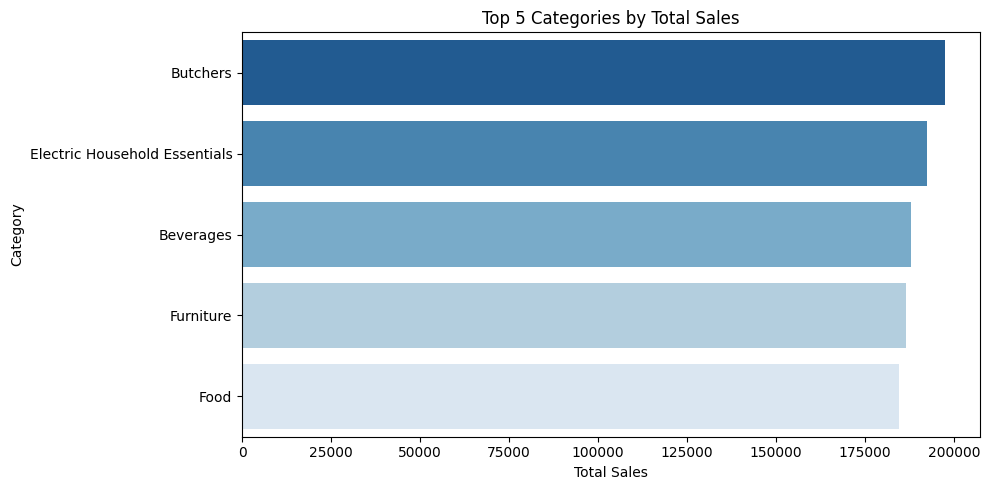

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Top 5 Categories by Total Sales
plt.figure(figsize=(10, 5))
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=category_sales.values, y=category_sales.index,
            hue=category_sales.index, palette='Blues_r', legend=False)
plt.title('Top 5 Categories by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### What I found - Chart 1:
- Top category by total sales: Butchers (~200,000)
- Second: Electric Household Essentials (~195,000)
- Third: Beverages (~190,000)
- Fourth: Furniture (~188,000)
- Fifth: Food (~185,000)
- The top 5 categories have similar sales figures
  suggesting balanced demand across product types

## Step 17b: Total Sales by Location

**Why:** I want to know whether Online or In-store
transactions generate more revenue. This helps understand
which sales channel is more important for the business.

**What the code does:** Groups the data by Location, sums
Total Spent for each, and displays a bar chart.

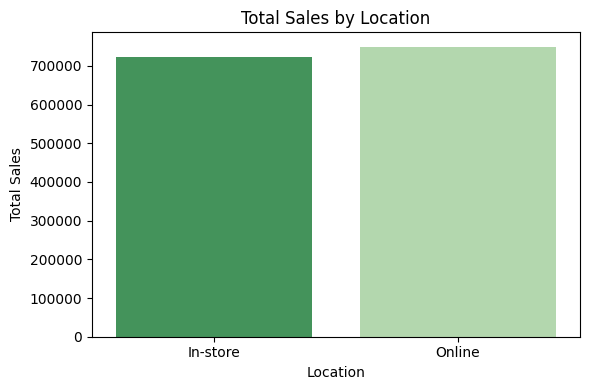

In [25]:
plt.figure(figsize=(6, 4))
location_sales = df.groupby('Location')['Total Spent'].sum()
sns.barplot(x=location_sales.index, y=location_sales.values,
            hue=location_sales.index, palette='Greens_r', legend=False)
plt.title('Total Sales by Location')
plt.xlabel('Location')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### What I found - Chart 2:
- In-store total sales: approximately 715,000
- Online total sales: approximately 730,000
- Online sales are slightly higher than In-store
- Both channels contribute almost equally to total
  revenue suggesting the business serves both
  online and physical customers effectively

## Step 17c: Total Sales by Payment Method

**Why:** I want to know which payment method customers
use most. This helps understand customer payment
preferences and can inform business decisions around
payment infrastructure.

**What the code does:** Groups the data by Payment Method,
sums Total Spent for each, and displays a bar chart.

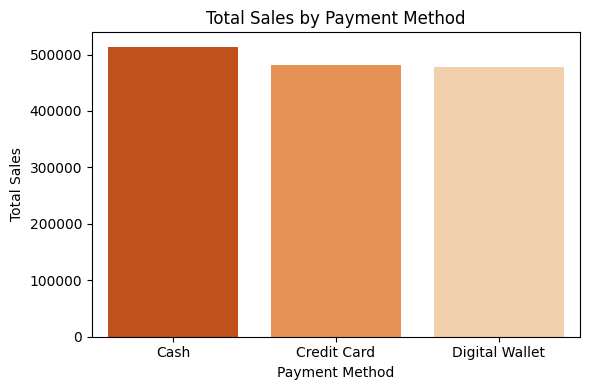

In [26]:
plt.figure(figsize=(6, 4))
payment_sales = df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)
sns.barplot(x=payment_sales.index, y=payment_sales.values,
            hue=payment_sales.index, palette='Oranges_r', legend=False)
plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### What I found - Chart 3:
- Cash: approximately 510,000 in total sales (highest)
- Credit Card: approximately 480,000
- Digital Wallet: approximately 470,000
- Cash is the most preferred payment method
- All three payment methods are relatively close
  suggesting customers use a mix of payment options

## Step 18: Export Clean Dataset

**Why:** The pipeline is complete. I need to save the cleaned
dataset as a CSV file so it can be used for further analysis
or submitted as a deliverable.

**What the code does:** Saves the final cleaned DataFrame as
a CSV file called clean_retail_store_sales.csv without the
row index numbers.

In [27]:
# Export clean dataset
df.to_csv('clean_retail_store_sales.csv', index=False)

# Verify the export
print(f"Clean dataset exported successfully.")
print(f"Final row count: {df.shape[0]}")
print(f"Final column count: {df.shape[1]}")
print(f"Filename: clean_retail_store_sales.csv")

Clean dataset exported successfully.
Final row count: 11362
Final column count: 17
Filename: clean_retail_store_sales.csv


### Pipeline Complete.

clean_retail_store_sales.csv exported successfully.

Final dataset summary:
- Rows: 11,362 (started with 12,575, removed 1,213 rows
  with missing Item values)
- Columns: 17 (original 11 + 6 new encoded and scaled columns)
- Zero missing values
- All data types correct
- Three analysis charts produced

The pipeline is complete.